## Methodology and explanation

We conducted this analysis to evaluate how well two distinct LSTM models generalize to new, unseen data. We applied models trained on a previous dataset (House 1) to a completely new and unseen dataset (House 2) to determine which architecture offers better predictive performance in a real-world transfer learning scenario.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

In [4]:
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/a/'

# LSTM models for comparison
model_1_path = base_path + 'house1_trained_hourly_lstm_model.keras' # simple univariate model
model_2_path = base_path + 'greg_lstm.keras' # complex multi-lag features

# Unseen house 2 dataset
file_path = base_path + 'House_2_cleaned.csv'
df_model_1 = pd.read_csv(file_path, parse_dates=['index'], index_col='index')
df_model_2 = pd.read_csv(file_path, parse_dates=['index'], index_col='index')

Mounted at /content/drive


## Pre-processing for respective models

### Model 1, the simple univariate model

In [2]:
lb_1 = 168

def preprocess_model_1(input_df):
    data = input_df[['power_watts']].values

    # Scale to [0, 1]
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data)

    return data_scaled, scaler

def create_sequences_1(dataset, look_back=lb_1):
    X, y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i-look_back:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

### Model 2, the complex multi-lag feature model

In [5]:
lb_2 = 120

def preprocess_model_2(input_df):
    data = input_df.copy()

    # Replicated feature engineering for rolling & lag fields
    data['hour'] = data.index.hour
    data['dayofweek'] = data.index.dayofweek
    data['is_weekend'] = (data['dayofweek'] >= 5).astype(int)
    data['roll_24_mean'] = data['power_watts'].rolling(24).mean()
    data['roll_48_mean'] = data['power_watts'].rolling(48).mean()
    data['roll_24_std'] = data['power_watts'].rolling(24).std()
    data['roll_6_mean'] = data['power_watts'].rolling(6).mean()
    data['roll_12_mean'] = data['power_watts'].rolling(12).mean()
    data['roll_48_std'] = data['power_watts'].rolling(48).std()
    data['lag_1'] = data['power_watts'].shift(1)
    data['lag_24'] = data['power_watts'].shift(24)
    data['lag_2'] = data['power_watts'].shift(2)
    data['lag_6'] = data['power_watts'].shift(6)
    data['lag_12'] = data['power_watts'].shift(12)
    data['lag_48'] = data['power_watts'].shift(48)
    data['lag_168'] = data['power_watts'].shift(168)

    data = data.dropna()

    feature_cols = [
        'power_watts', 'hour', 'dayofweek', 'is_weekend',
        'roll_24_mean', 'roll_48_mean', 'roll_24_std',
        'roll_6_mean', 'roll_12_mean', 'roll_48_std',
        'lag_1', 'lag_24', 'lag_2', 'lag_6', 'lag_12', 'lag_48', 'lag_168'
    ]

    # Scale features
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data[feature_cols])
    scaler_target = MinMaxScaler()
    scaler_target.fit(data[['power_watts']])

    return data_scaled, scaler_target

def create_sequences_2(data, look_back=lb_2):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

## Pre-processing for respective models

### Model 1, the simple univariate model

In [6]:
def preprocess_model_1(input_df):
    data = input_df[['power_watts']].values
    scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data)

    return data_scaled, scaler

def create_sequences_1(dataset, look_back=lb_1):
    X, y = [], []
    for i in range(look_back, len(dataset)):
        X.append(dataset[i-look_back:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

### Model 2, the complex multi-lag feature model

In [7]:
def preprocess_model_2(input_df):
    data = input_df.copy()

    # Replicated feature engineering for rolling & lag fields
    data['hour'] = data.index.hour
    data['dayofweek'] = data.index.dayofweek
    data['is_weekend'] = (data['dayofweek'] >= 5).astype(int)
    data['roll_24_mean'] = data['power_watts'].rolling(24).mean()
    data['roll_48_mean'] = data['power_watts'].rolling(48).mean()
    data['roll_24_std'] = data['power_watts'].rolling(24).std()
    data['roll_6_mean'] = data['power_watts'].rolling(6).mean()
    data['roll_12_mean'] = data['power_watts'].rolling(12).mean()
    data['roll_48_std'] = data['power_watts'].rolling(48).std()
    data['lag_1'] = data['power_watts'].shift(1)
    data['lag_24'] = data['power_watts'].shift(24)
    data['lag_2'] = data['power_watts'].shift(2)
    data['lag_6'] = data['power_watts'].shift(6)
    data['lag_12'] = data['power_watts'].shift(12)
    data['lag_48'] = data['power_watts'].shift(48)
    data['lag_168'] = data['power_watts'].shift(168)

    data = data.dropna()

    feature_cols = [
    'power_watts',
    'hour', 'dayofweek', 'is_weekend',
    'roll_24_mean', 'roll_48_mean', 'roll_24_std',
    'roll_6_mean', 'roll_12_mean', 'roll_48_std',
    'lag_1', 'lag_24',
    'lag_2', 'lag_6', 'lag_12', 'lag_48', 'lag_168'
]

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data[feature_cols])
    scaler_target = MinMaxScaler()
    scaler_target.fit(data[['power_watts']])

    return data_scaled, scaler_target

def create_sequences_2(data, look_back=lb_2):
    X, y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i-look_back:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

## Predictions for respective models

### Model 1, the simple univariate model

In [8]:
data_1_scaled, scaler_1 = preprocess_model_1(df_model_1)
X_1, y_1 = create_sequences_1(data_1_scaled, look_back=lb_1)
X_1 = np.reshape(X_1, (X_1.shape[0], X_1.shape[1], 1))

model_1 = tf.keras.models.load_model(model_1_path)
pred_1_scaled = model_1.predict(X_1)
pred_1 = scaler_1.inverse_transform(pred_1_scaled)
actual_1 = scaler_1.inverse_transform(y_1.reshape(-1, 1))

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


171/171 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step


### Model 2, the complex multi-lag feature model

In [9]:
data_2_scaled, scaler_2_target = preprocess_model_2(df_model_2)
X_2, y_2 = create_sequences_2(data_2_scaled, look_back=lb_2)

model_2 = tf.keras.models.load_model(model_2_path)
pred_2_scaled = model_2.predict(X_2)
pred_2 = scaler_2_target.inverse_transform(pred_2_scaled)
actual_2 = scaler_2_target.inverse_transform(y_2.reshape(-1, 1))

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 24 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


167/167 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step


## Results

In [18]:
rmse_1 = np.sqrt(mean_squared_error(actual_1, pred_1))
mae_1 = mean_absolute_error(actual_1, pred_1)

rmse_2 = np.sqrt(mean_squared_error(actual_2, pred_2))
mae_2 = mean_absolute_error(actual_2, pred_2)

print("** RSME **")
print(f"Model 1 (simple univariate):    {rmse_1:.2f} watts")
print(f"Model 2 (multivariate w/ lags): {rmse_2:.2f} watts")

print("\n** MAE **")
print(f"Model 1 (simple univariate):    {mae_1:.2f} watts")
print(f"Model 2 (multivariate w/ lags): {mae_2:.2f} watts")

** RSME **
Model 1 (simple univariate):    217.66 watts
Model 2 (multivariate w/ lags): 251.87 watts

** MAE **
Model 1 (simple univariate):    122.44 watts
Model 2 (multivariate w/ lags): 161.87 watts


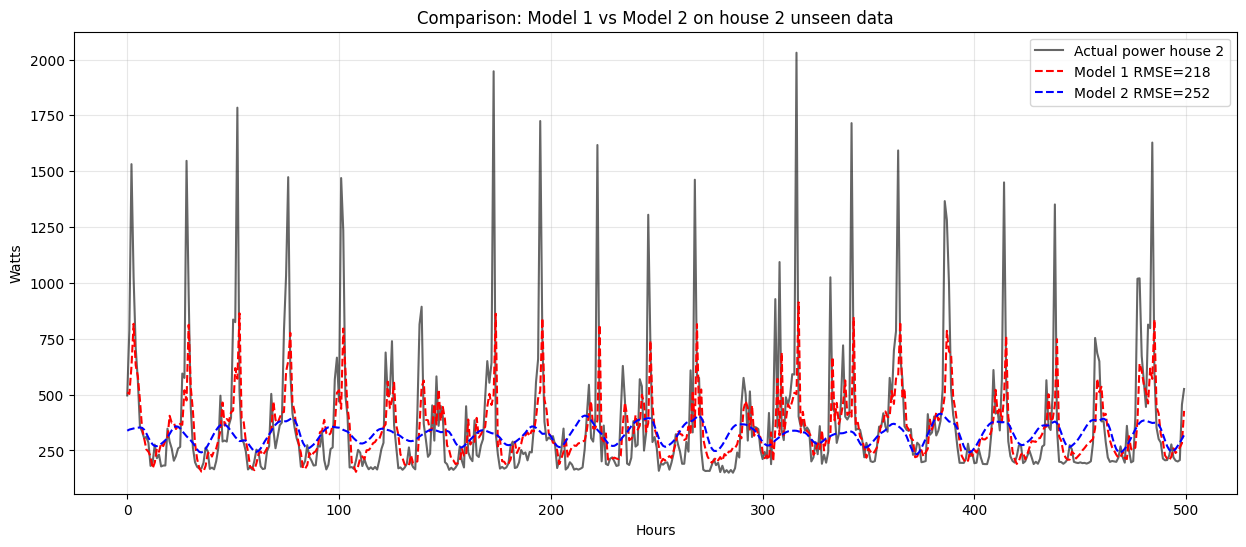

In [23]:
plt.figure(figsize=(15, 6))

limit = 500 # sample

plt.plot(actual_1[:limit], label='Actual power house 2', color='black', alpha=0.6)
plt.plot(pred_1[:limit], label=f'Model 1 RMSE={rmse_1:.0f}', color='red', linestyle='--')
plt.plot(pred_2[:limit], label=f'Model 2 RMSE={rmse_2:.0f}', color='blue', linestyle='--')

plt.title('Comparison: Model 1 vs Model 2 on house 2 unseen data')
plt.ylabel('Watts')
plt.xlabel('Hours')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusions:

Our analysis demonstrates that the simpler, univariate model (model 1) significantly outperformed the complex multivariate model with lag features(model 2) on the unseen House 2 dataset. Model 1 reduced the error by approximately 34 watts in RMSE and 39 watts in MAE compared to model 2.

We attribute this performance gap to the complexity of Model 2. While model 2 likely performed well on its original training data, its reliance on specific engineered lags and rolling windows made it brittle when applied to a new household with different energy consumption patterns. In contrast, model 1's reliance on raw historical data allowed it to adapt more robustly to the new environment.

In the comparison chart, we seen an interesting trend. Model 1, which is indicated by the red line, tracks well against the peaks of the actual power usage. It doesn't do an excellent job of capturing the magnitude, but it does capture the occurrence. Model 2 in blue shows a more smooth prediction of the peaks. It overestimates the drops and underestimates the peaks. Use the lag and rolling features here is likely making the signals more muted.